Data:
https://www.kaggle.com/uciml/pima-indians-diabetes-database

Load the dataset<p>
Perform exploratory data analysis


1. Target variable distribution
2. Examine missing values
3. Examine data types
4. Examine data distribution
5. Examine data intercorrelations


<p>
5 pts.



In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error, r2_score, explained_variance_score
d_data = pd.read_csv('/content/drive/MyDrive/INFO 367/Week4/diabetes.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Q1**: This shows the histogram of the target variable and it shows that 1 is having diabetes and 0 is not.

<Axes: >

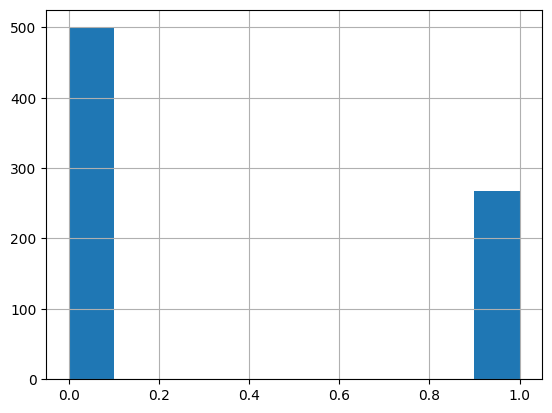

In [ ]:
d_data.Outcome.hist()

In [ ]:
d_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
d_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Q3: The only data type we have to change is Outcome to a categorical value in order to create our model

In [ ]:
d_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
d_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Q2:** There are no missing values at all in our dataset

<Axes: >

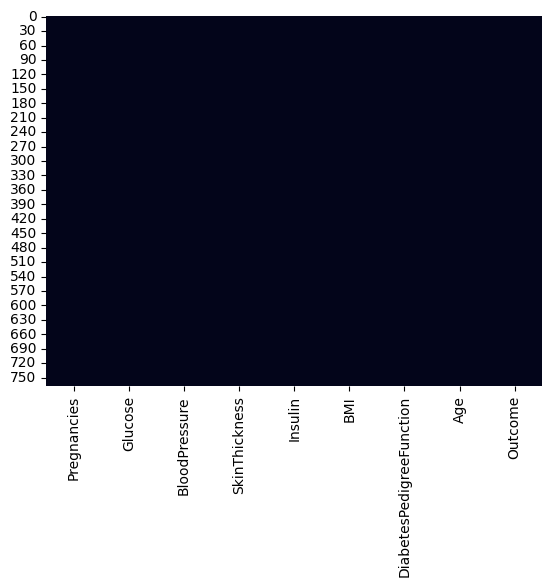

In [ ]:
sns.heatmap(d_data.isnull(), cbar=False)

**Q4**: The data distribution shows that some datasets are invalid such as glucose, bloodpressure, Bmi and Insulin being 0. These values in reality can't be 0.

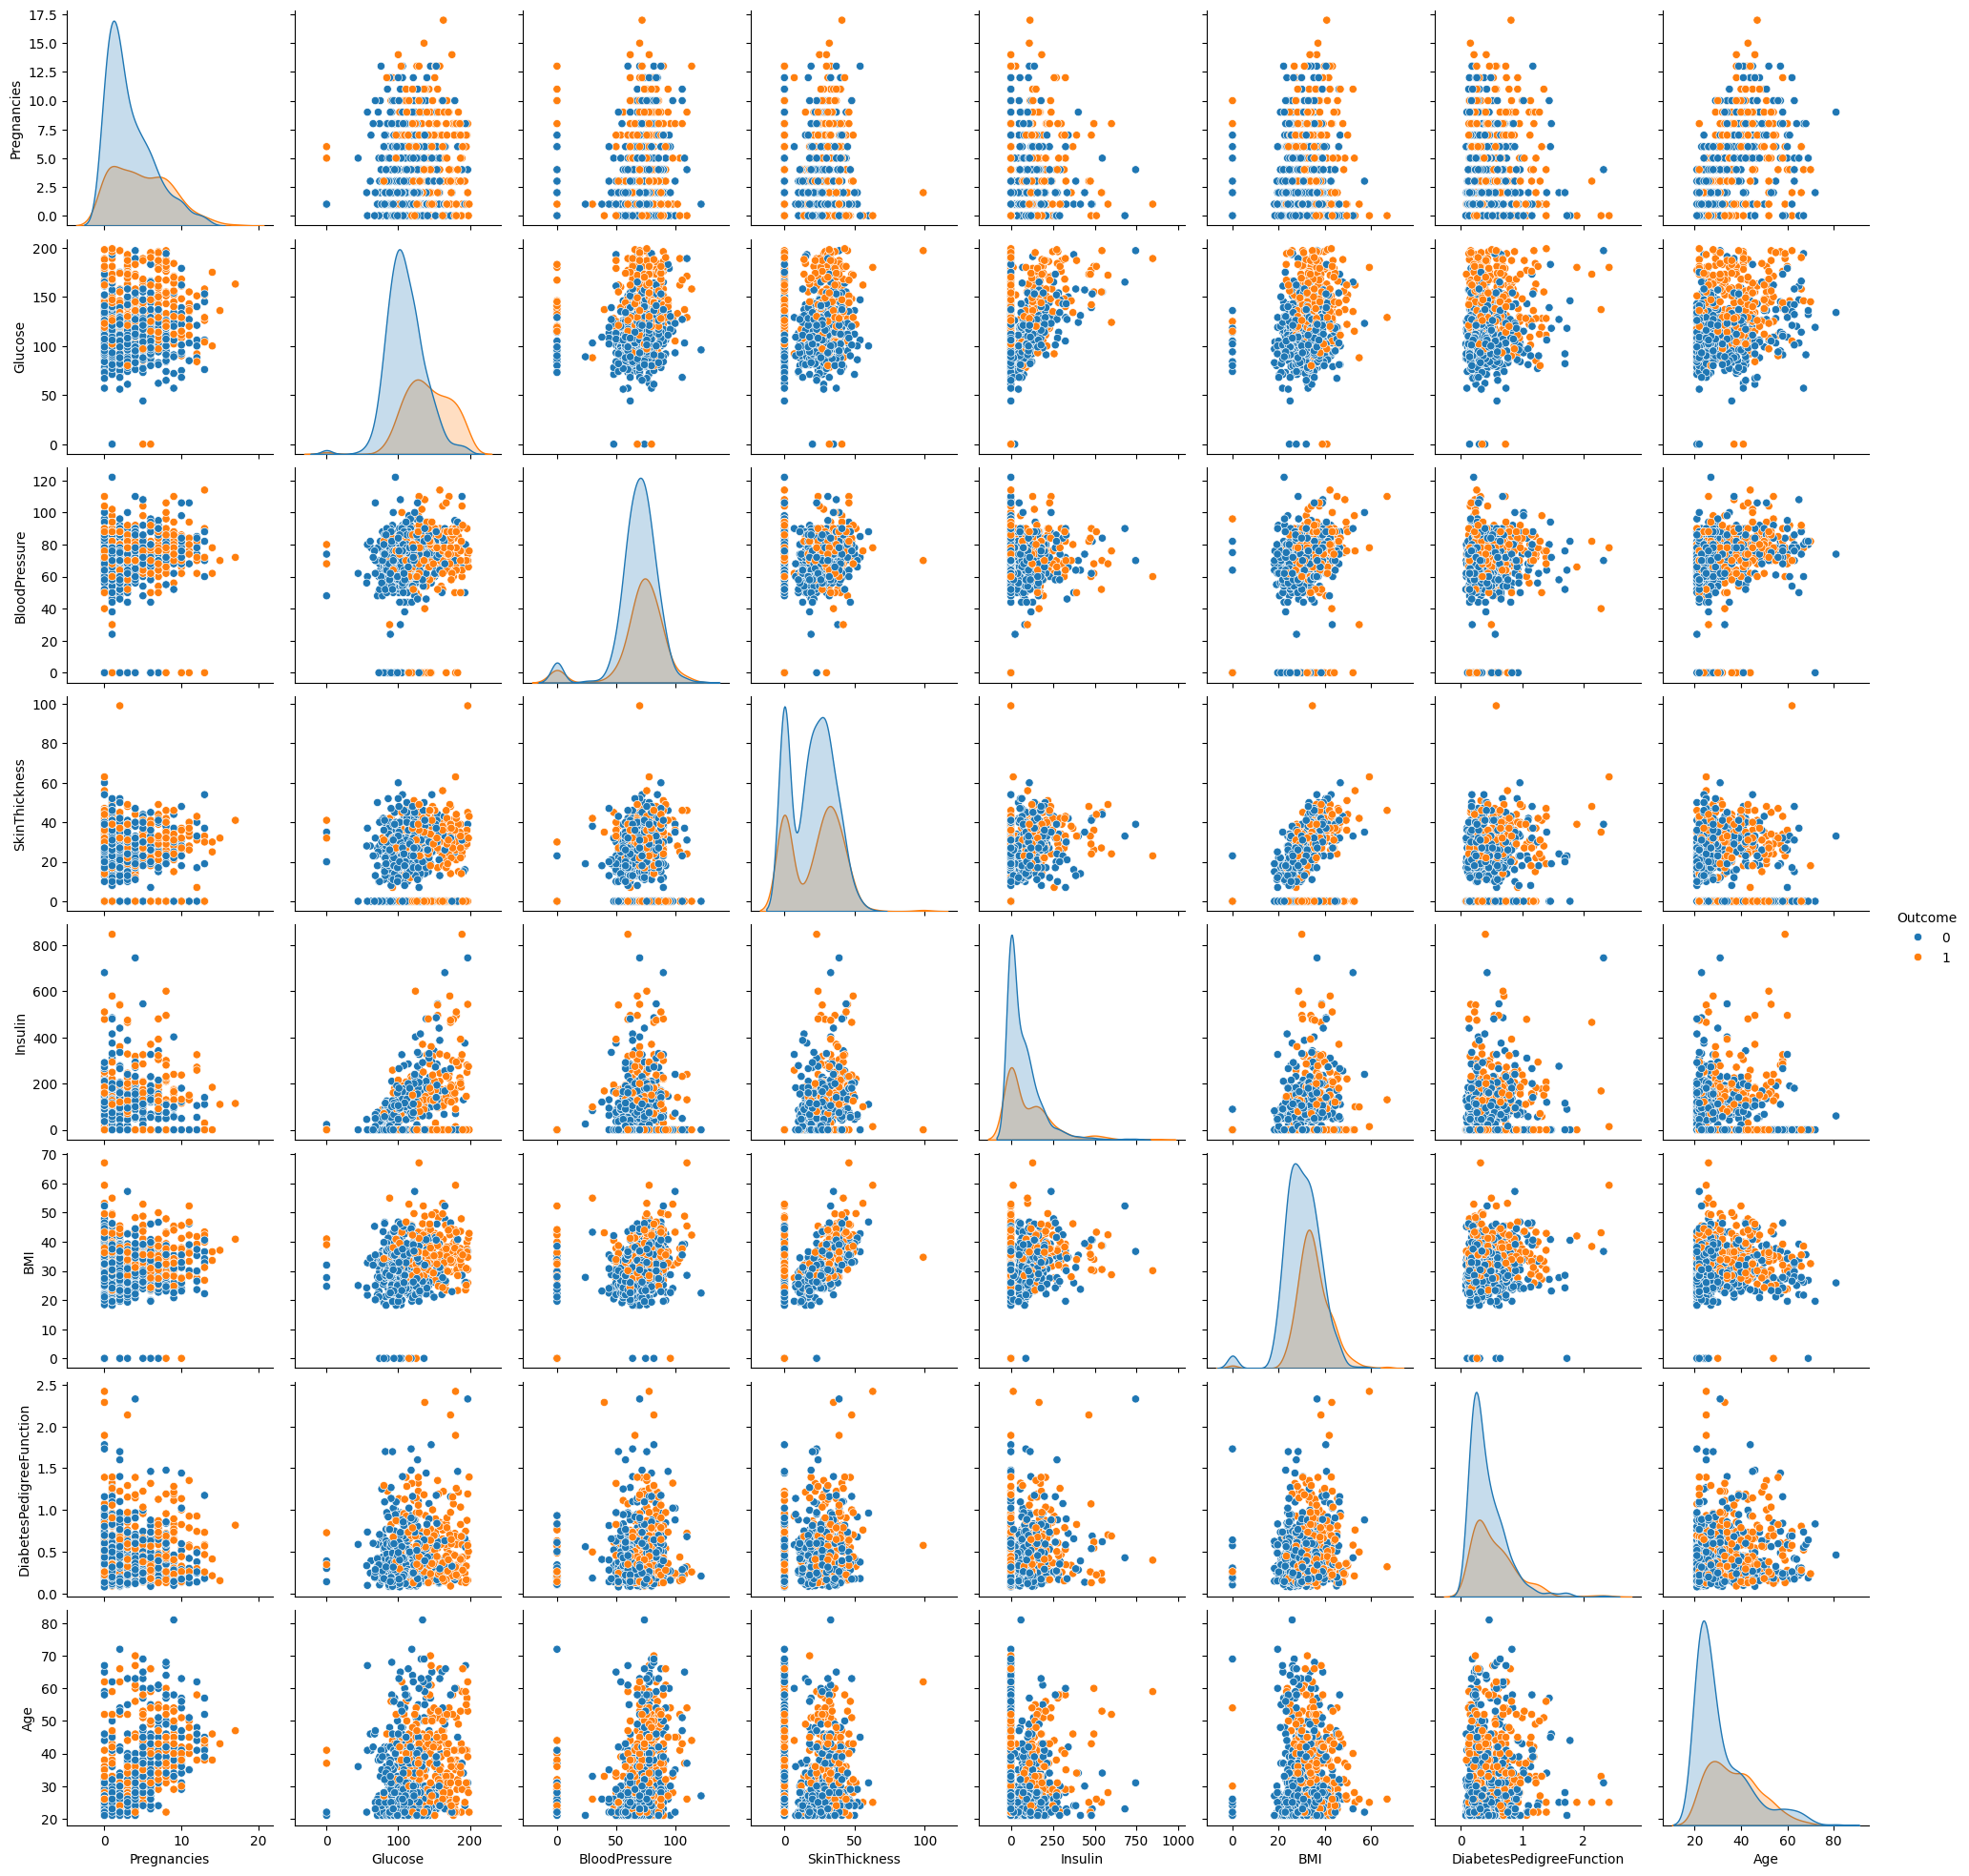

In [ ]:
sns.pairplot(d_data, hue = 'Outcome')

Here I dropped every value that seemed impossible or unlikely to happen in a actual study and to disrupt our model.

In [ ]:
d_data.drop(d_data[d_data['Glucose'] < 5 ].index, inplace=True)
d_data.drop(d_data[d_data['BloodPressure'] < 5].index, inplace=True)
d_data.drop(d_data[d_data['Insulin'] < 5 ].index, inplace=True)
d_data.drop(d_data[d_data['BMI'] < 5 ].index, inplace=True)
d_data.drop(d_data[d_data['Pregnancies'] > 15 ].index, inplace=True)

Q5: Skinthickness and BMI are intercollerations or multicollinearity from the way it curves and we can also see inculin and glucose also having some kind of intercolleration but it is more of a maybe. This will impact our model and might cause an error.

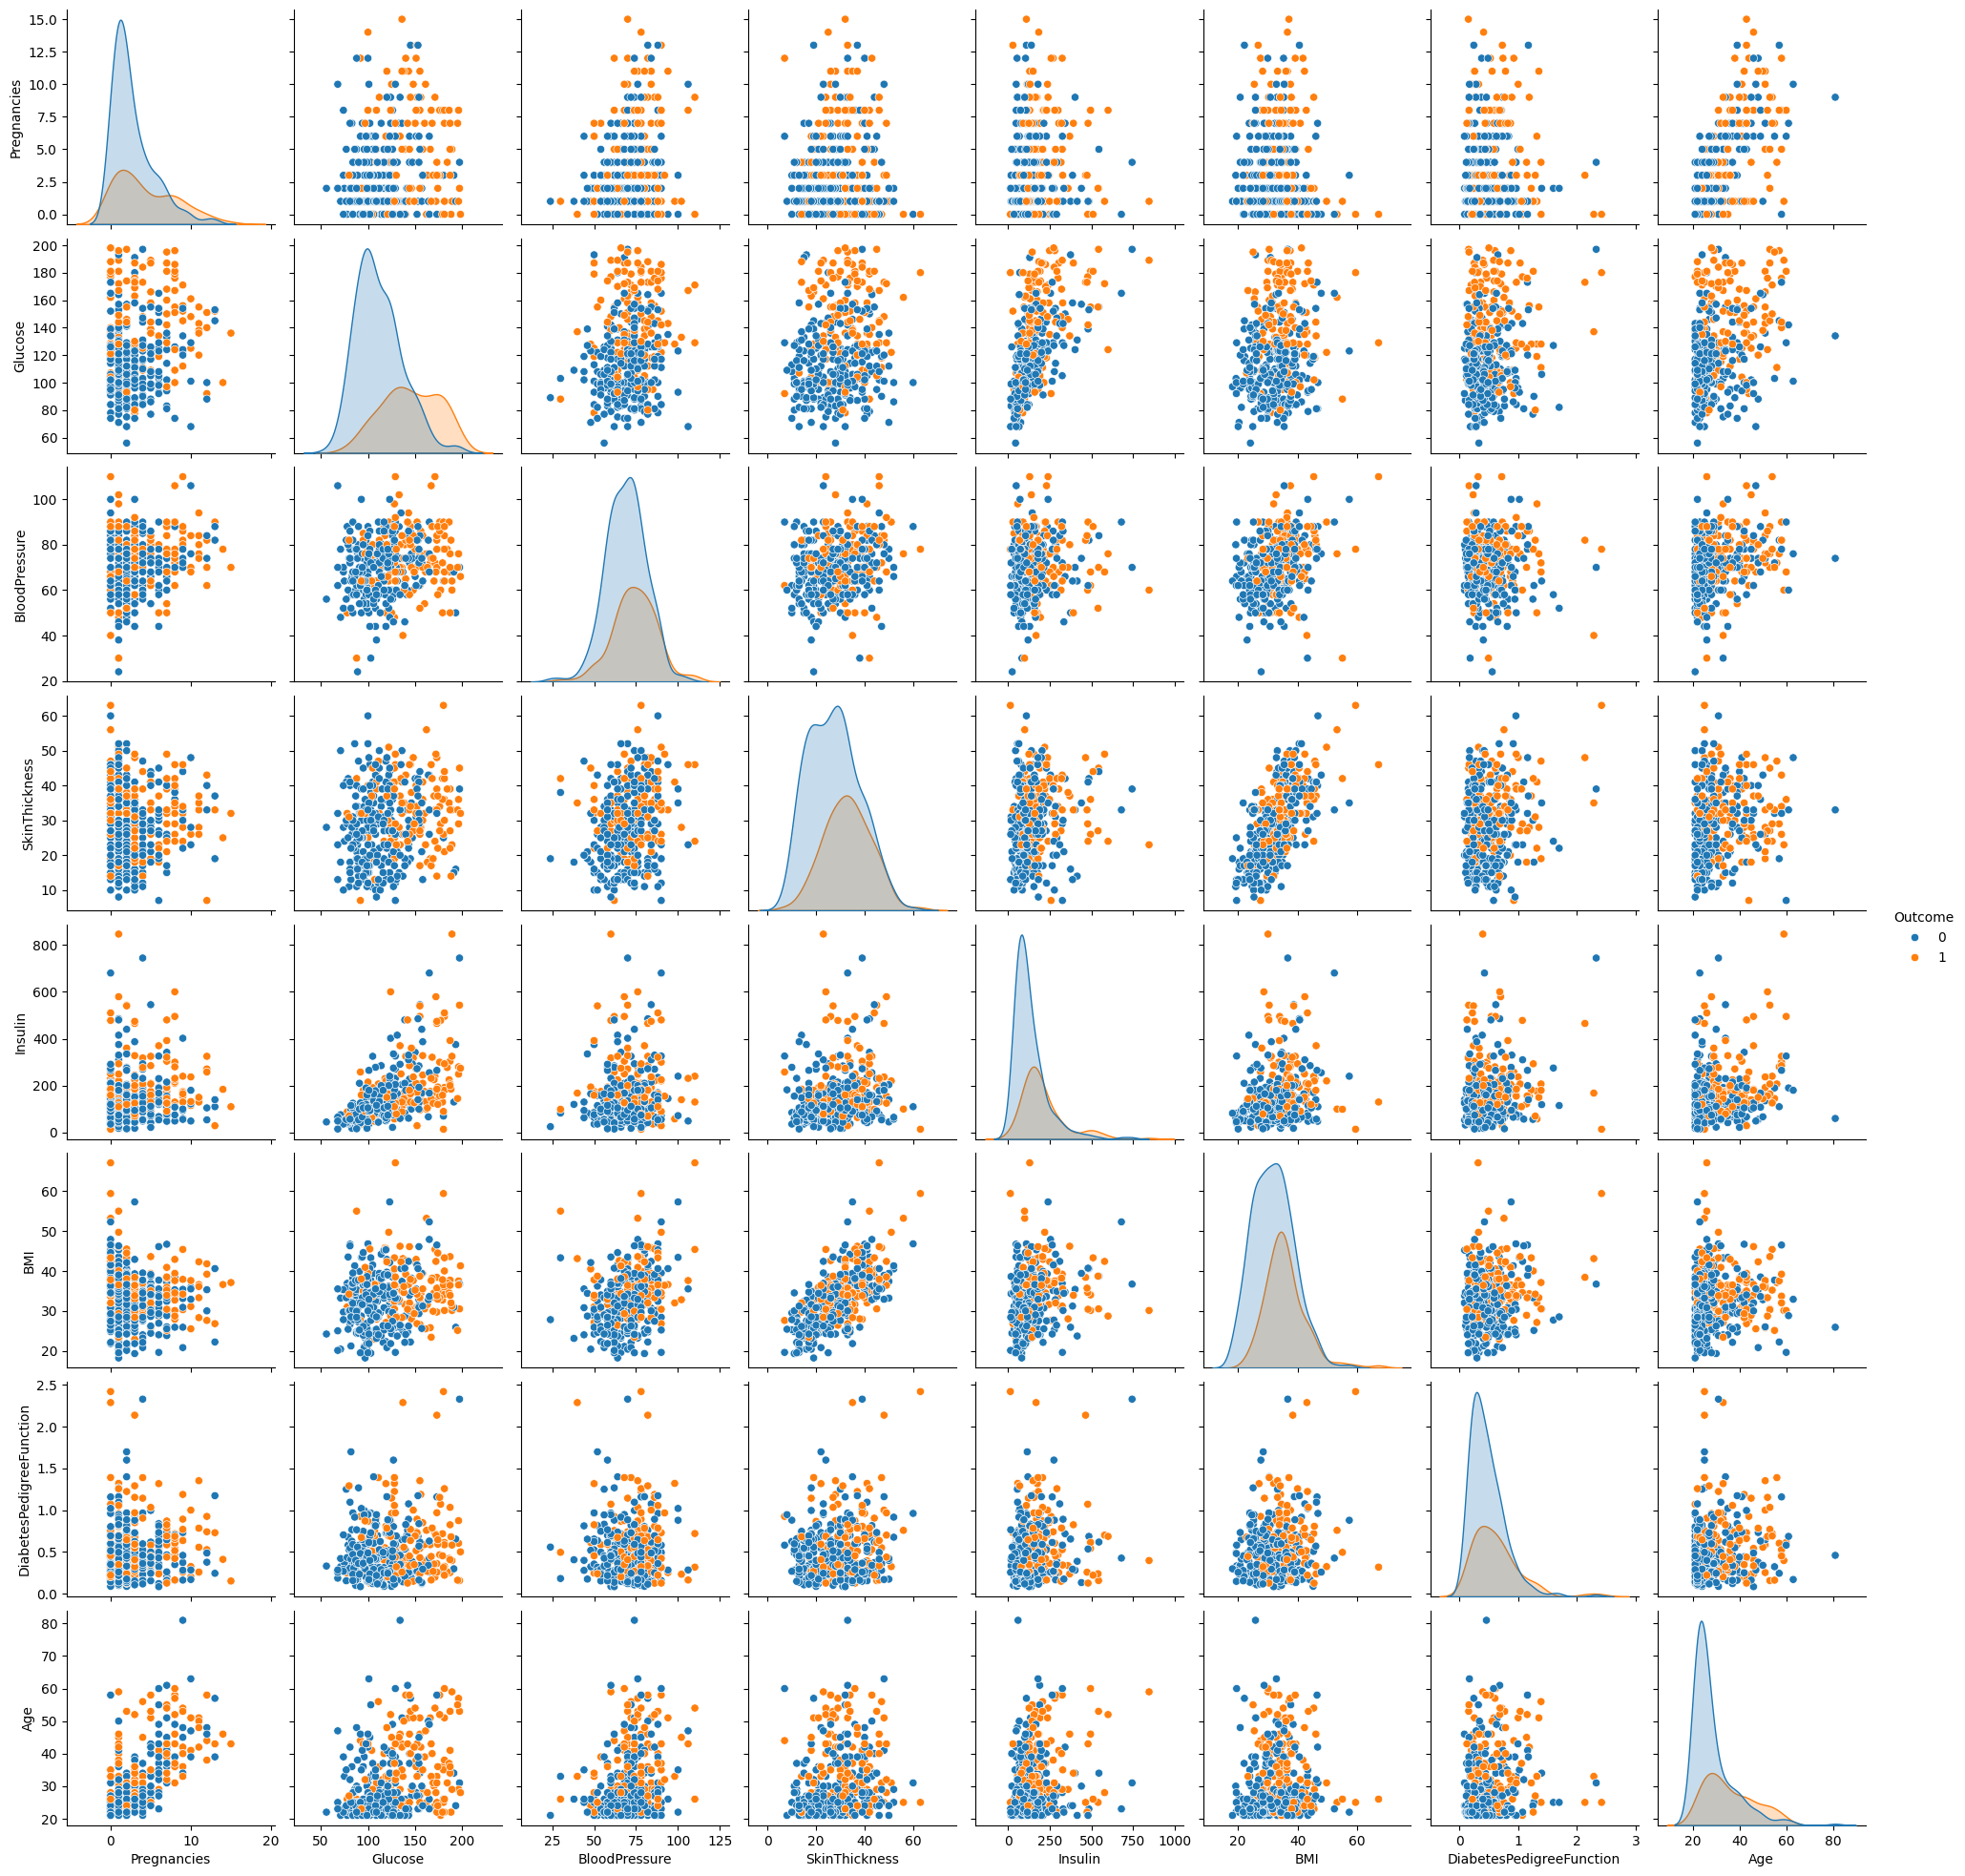

In [ ]:
sns.pairplot(d_data, hue = 'Outcome')

Here I changed the outcome to a category so it can be used in our logistic regression model or else it would output a categorical error.

In [ ]:
d_data['Outcome'] =  d_data['Outcome'].astype('category',copy=False)

In [ ]:
d_data_clean = pd.get_dummies(d_data, drop_first=True)

In [ ]:
d_data_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,391.000000,391.000000,391.000000,391.00000,391.000000,391.000000,391.000000,391.000000
mean,3.265985,122.524297,70.659847,29.11509,156.163683,33.066240,0.522294,30.823529
std,3.139630,30.832447,12.511918,10.51273,118.974847,7.025502,0.345609,10.181031
min,0.000000,56.000000,24.000000,7.00000,14.000000,18.200000,0.085000,21.000000
25%,1.000000,99.000000,62.000000,21.00000,76.500000,28.400000,0.269500,23.000000
50%,2.000000,119.000000,70.000000,29.00000,126.000000,33.200000,0.447000,27.000000
75%,5.000000,143.000000,78.000000,36.50000,190.000000,37.050000,0.684500,36.000000
max,15.000000,198.000000,110.000000,63.00000,846.000000,67.100000,2.420000,81.000000


In [ ]:
d_data_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome_1
3,1,89,66,23,94,28.1,0.167,21,False
4,0,137,40,35,168,43.1,2.288,33,True
6,3,78,50,32,88,31.0,0.248,26,True
8,2,197,70,45,543,30.5,0.158,53,True
13,1,189,60,23,846,30.1,0.398,59,True


Split data 70/30 into training and test datasets.<p>
Build a logistic regression model to predict diabetes<p>

5 pts.

In [ ]:
X = d_data_clean.drop('Outcome_1', axis=1)
y = d_data_clean['Outcome_1']

In [ ]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
6,3,78,50,32,88,31.0,0.248,26
8,2,197,70,45,543,30.5,0.158,53
13,1,189,60,23,846,30.1,0.398,59


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(solver='liblinear')

logmodel.fit(X_train,y_train)

LogisticRegression(solver='liblinear')

In [ ]:
y_pred = logmodel.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix(y_test,y_pred)

array([[75, 13],
       [12, 18]])

Evaluate model performance. <p>
Display the confusion matrix.<p>
Report the following metrics:

1.   ROC AUC
2.   Accuracy
<li>Recall
<li>Precision
<li>Display the ROC curve.
<p>

5 pts.





This shows the false class which is No diabetes which is .86 and .85 for the precision and recall which are very good for the model while true has .58 and .60 which might cause some error.

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.86      0.85      0.86        88
        True       0.58      0.60      0.59        30

    accuracy                           0.79       118
   macro avg       0.72      0.73      0.72       118
weighted avg       0.79      0.79      0.79       118



In [ ]:
logmodel.coef_

array([[ 0.10112842,  0.0231653 , -0.02408073,  0.00925392,  0.00093537,
         0.02766532,  0.39409963,  0.01532967]])

This shows the p values for the data, anything more than .05 is too much and we can see SkinThickness, Insulin, BMI, DiabetesPedigreeFunction and Age are way above it and will impact our model so we will have to create a new model to fix this.

In [ ]:
import statsmodels.api as sm
logit_model=sm.Logit(y_train, X_train)
logmodel_2=logit_model.fit()
print(logmodel_2.summary2())

Optimization terminated successfully.
         Current function value: 0.586270
         Iterations 5
                             Results: Logit
Model:                 Logit              Method:             MLE       
Dependent Variable:    Outcome_1          Pseudo R-squared:   0.105     
Date:                  2024-10-15 23:23   AIC:                336.1033  
No. Observations:      273                BIC:                364.9790  
Df Model:              7                  Log-Likelihood:     -160.05   
Df Residuals:          265                LL-Null:            -178.79   
Converged:             1.0000             LLR p-value:        3.7983e-06
No. Iterations:        5.0000             Scale:              1.0000    
------------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------------
Pregnancies               0.1230   0.0581  2.1185 0

This Roc Model shows the curve that goes up to the right which shows that this is a passable model. The Roc Auc is 0.84 which means this is above 0.50 which is a model that we will use but change later in this worksheet.

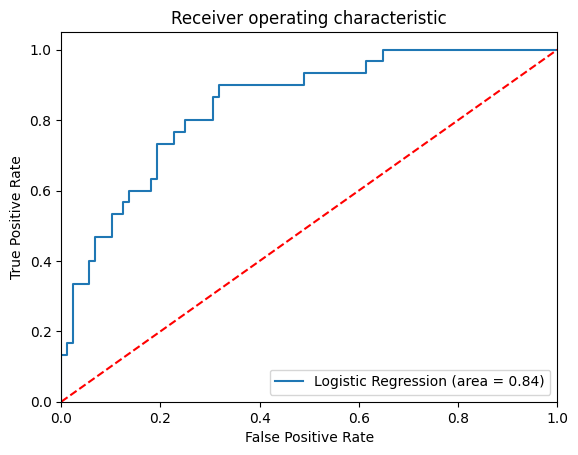

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

logit_roc_auc = roc_auc_score(y_test, logmodel.predict_proba(X_test)[:,1])
fpr, tpr, thresholds = roc_curve(y_test, logmodel.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

In [ ]:
d_data['Outcome'] = pd.to_numeric(d_data['Outcome'])

print('Chance Rate of Obtaining Diabetes: ', d_data.Outcome.mean())

Chance Rate of Obtaining Diabetes:  0.329923273657289


Determine which features have no effect on the Outcome (Hint: you will need to use statsmodels). <p>
Exclude  features with non-statistically significant effects in the model, rebuild the model and assess how the reduced feature set affects model performance.

5 pts.

Here I took the p value of anything more than .05 and removed them from the data and created a whole new model as well as added the old and new Roc Auc to show the difference. We can see that it made little difference and that our model is still possible.

In [ ]:
import statsmodels.api as sm
import pandas as pd

logit_model = sm.Logit(y_train, X_train)
logmodel_result = logit_model.fit()

p_values = logmodel_result.pvalues
a = 0.05

insignificant_features = p_values[p_values > a].index.tolist()

X_train_reduced = X_train.drop(columns=insignificant_features)
X_test_reduced = X_test.drop(columns=insignificant_features)

logit_model_reduced = sm.Logit(y_train, X_train_reduced)
logmodel_reduced_result = logit_model_reduced.fit()

print(logmodel_reduced_result.summary2())


from sklearn.metrics import roc_auc_score

logit_roc_auc_original = roc_auc_score(y_test, logmodel_result.predict(X_test))
logit_roc_auc_reduced = roc_auc_score(y_test, logmodel_reduced_result.predict(X_test_reduced))

print("Original Model ROC AUC:", logit_roc_auc_original)
print("Reduced Model ROC AUC:", logit_roc_auc_reduced)

Optimization terminated successfully.
         Current function value: 0.586270
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.593990
         Iterations 5
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: Outcome_1        Pseudo R-squared: 0.093     
Date:               2024-10-15 23:45 AIC:              330.3185  
No. Observations:   273              BIC:              341.1469  
Df Model:           2                Log-Likelihood:   -162.16   
Df Residuals:       270              LL-Null:          -178.79   
Converged:          1.0000           LLR p-value:      5.9692e-08
No. Iterations:     5.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
Pregnancies        0.1349   0.

In [ ]:
import statsmodels.api as sm
import pandas as pd
from sklearn.metrics import classification_report

y_pred_reduced = logmodel_reduced_result.predict(X_test_reduced)

y_pred_classes = (y_pred_reduced > 0.5).astype(int)

report = classification_report(y_test, y_pred_classes)
print(report)

              precision    recall  f1-score   support

       False       0.85      0.84      0.85        88
        True       0.55      0.57      0.56        30

    accuracy                           0.77       118
   macro avg       0.70      0.70      0.70       118
weighted avg       0.77      0.77      0.77       118

